# SAR–Optical Feature Fusion for Crop Classification
## Week 3 — Optical Analysis and SAR Data-Quality Audit

**Study region:** Argentina and Brazil  
**Dataset:** YieldSAT-derived sample records  
**Purpose:** Inspect the optical samples, calculate/verify NDVI, visualize Sentinel-1 test data, and document whether SAR–optical matching is currently possible.

> **Important limitation:** The supplied SAR field-extraction CSV has empty VV/VH values and empty geometries. The SAR TIFF is a test raster, not a confirmed crop-field sample. Therefore this notebook does **not** claim completed SAR-optical fusion.

## 1. Objective

1. Load and inspect the available Argentina, Brazil, optical-feature, SAR-sample, and SAR-raster files.
2. Check sample IDs, crop labels, dates, missing values, and duplicate records.
3. Calculate or verify NDVI using Sentinel-2 B08 and B04.
4. Produce exploratory plots and summary statistics.
5. Inspect the Sentinel-1 VV/VH test raster.
6. Record the data-alignment limitation and save outputs for the Week-3 report.

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from IPython.display import display

DATA_DIR = Path("/content")
required_files = [
    "Argentina_with_coordinates.csv",
    "Brazil_with_coordinates.csv",
    "Optical_Features.csv",
    "SAR_Field_VV_VH_Samples.csv",
    "SAR_VV_VH_Test.tif",
]

missing = [f for f in required_files if not (DATA_DIR / f).exists()]
if missing:
    try:
        from google.colab import files
        print("Upload these files:", missing)
        uploaded = files.upload()
        DATA_DIR = Path("/content")
    except ImportError:
        print("Files not found. Set DATA_DIR to the folder containing the required files.")

In [18]:
argentina = pd.read_csv(DATA_DIR / "Argentina_with_coordinates.csv")
brazil = pd.read_csv(DATA_DIR / "Brazil_with_coordinates.csv")
optical = pd.read_csv(DATA_DIR / "Optical_Features.csv")
sar_samples = pd.read_csv(DATA_DIR / "SAR_Field_VV_VH_Samples.csv")

print("Argentina shape:", argentina.shape)
print("Brazil shape:", brazil.shape)
print("Optical features shape:", optical.shape)
print("SAR field-sample table shape:", sar_samples.shape)

print("\nOptical columns:")
print(optical.columns.tolist())
display(optical.head())

Argentina shape: (50, 25)
Brazil shape: (50, 25)
Optical features shape: (100, 24)
SAR field-sample table shape: (100, 27)

Optical columns:
['index', 'farm_identifier', 'field_shared_name', 'crop', 'year', 'target', 'row', 'col', 'date', 'time_step', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'country', 'NDVI']


,index,farm_identifier,field_shared_name,crop,year,target,row,col,date,time_step,...,B05,B06,B07,B08,B09,B11,B12,B8A,country,NDVI
0,875ad00e-dea6-4c80-ac45-d79dd2cc2fb9,39,557,corn,2017,5.76,0,62,19-09-2016,8,...,1427,1671,1851,1976,2188,3496,2864,2125,Argentina,0.235000
1,4084ba43-e315-4477-9409-df8816c979f3,39,557,corn,2017,7.36,1,61,19-09-2016,8,...,1436,1792,1966,2018,2233,3445,2766,2243,Argentina,0.242611
2,2d0fd1b9-6f7e-4a22-ab64-eff3f345f427,39,557,corn,2017,11.62,1,62,19-09-2016,8,...,1405,1619,1782,1890,2164,3484,2877,2056,Argentina,0.223301
3,b86f270d-3be7-46ed-b85b-8385fbdbba3e,39,557,corn,2017,12.18,1,63,19-09-2016,8,...,1397,1538,1694,1800,2131,3493,2918,1961,Argentina,0.215395
4,96583946-ca16-4466-be2b-0d7244e8530e,39,557,corn,2017,12.03,1,64,19-09-2016,8,...,1410,1549,1700,1782,2136,3472,2888,1957,Argentina,0.194370


## 2. Data inspection and quality checks

The added `coord_x`, `coord_y`, and `coord_z` fields are not treated as longitude/latitude because their coordinate reference system and transformation have not been verified. The `row` and `col` values are raster-grid indices, not geographic coordinates.

In [19]:
for name, frame in [
    ("Argentina", argentina),
    ("Brazil", brazil),
    ("Optical features", optical),
    ("SAR field samples", sar_samples),
]:
    print(f"\\n--- {name} ---")
    print("Rows, columns:", frame.shape)
    print("Duplicate rows:", int(frame.duplicated().sum()))
    print("Missing values in key columns:")
    key_cols = [c for c in ["index", "field_shared_name", "crop", "date", "B04", "B08", "NDVI", "VV", "VH", ".geo"] if c in frame.columns]
    display(frame[key_cols].isna().sum().to_frame("missing_count"))

\n--- Argentina ---
Rows, columns: (50, 25)
Duplicate rows: 0
Missing values in key columns:


,missing_count
index,0
field_shared_name,0
crop,0
date,0
B04,0
B08,0


\n--- Brazil ---
Rows, columns: (50, 25)
Duplicate rows: 0
Missing values in key columns:


,missing_count
index,0
field_shared_name,0
crop,0
date,0
B04,0
B08,0


\n--- Optical features ---
Rows, columns: (100, 24)
Duplicate rows: 0
Missing values in key columns:


,missing_count
index,0
field_shared_name,0
crop,0
date,0
B04,0
B08,0
NDVI,0


\n--- SAR field samples ---
Rows, columns: (100, 27)
Duplicate rows: 0
Missing values in key columns:


,missing_count
index,0
field_shared_name,0
crop,0
date,0
B04,0
B08,0
VV,100
VH,100
.geo,0


In [20]:
print("Optical crop counts:")
display(optical["crop"].value_counts(dropna=False).rename_axis("crop").to_frame("records"))

print("Optical country counts:")
if "country" in optical.columns:
    display(optical["country"].value_counts(dropna=False).rename_axis("country").to_frame("records"))

print("Date examples:")
display(optical[["date", "year"]].head(10) if {"date", "year"}.issubset(optical.columns) else optical[["date"]].head(10))

Optical crop counts:


,records
crop,
corn,34
soybean,34
wheat,32


Optical country counts:


,records
country,
Argentina,50
Brazil,50


Date examples:


,date,year
0,19-09-2016,2017
1,19-09-2016,2017
2,19-09-2016,2017
3,19-09-2016,2017
4,19-09-2016,2017
5,19-09-2016,2017
6,19-09-2016,2017
7,19-09-2016,2017
8,19-09-2016,2017
9,19-09-2016,2017


## 3. NDVI calculation and verification

NDVI is calculated as:

\[
NDVI = \frac{B08 - B04}{B08 + B04}
\]

Rows where the denominator is zero or either input band is missing are marked missing. The notebook compares the calculated NDVI with the supplied NDVI column when present.

In [21]:
denominator = optical["B08"] + optical["B04"]
optical["NDVI_recalculated"] = np.where(
    denominator != 0,
    (optical["B08"] - optical["B04"]) / denominator,
    np.nan
)

if "NDVI" in optical.columns:
    difference = (optical["NDVI"] - optical["NDVI_recalculated"]).abs()
    print("Rows with supplied NDVI:", int(optical["NDVI"].notna().sum()))
    print("Maximum absolute difference (supplied vs recalculated):", float(difference.max()))
else:
    optical["NDVI"] = optical["NDVI_recalculated"]

print("Recalculated NDVI summary:")
display(optical["NDVI_recalculated"].describe().to_frame("NDVI"))
print("NDVI missing values:", int(optical["NDVI_recalculated"].isna().sum()))

Rows with supplied NDVI: 100
Maximum absolute difference (supplied vs recalculated): 4.980443280011571e-10
Recalculated NDVI summary:


,NDVI
count,100.000000
mean,0.356619
std,0.147637
min,0.188425
25%,0.223291
50%,0.289264
75%,0.484280
max,0.676349


NDVI missing values: 0


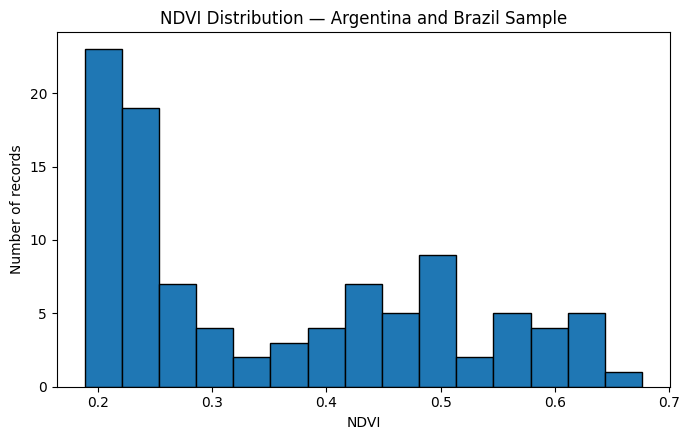

<Figure size 700x450 with 0 Axes>

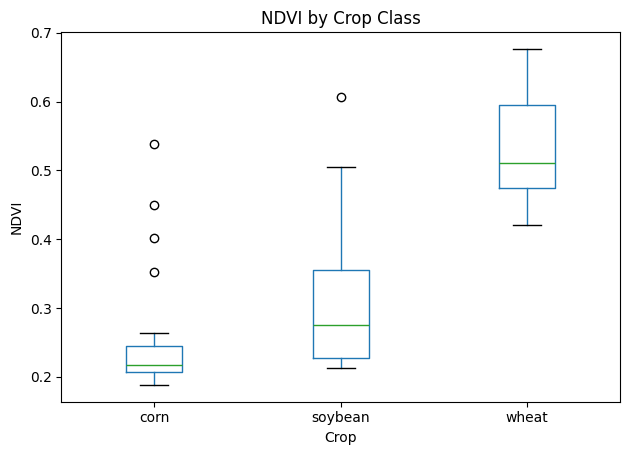

In [22]:
# NDVI histogram
plt.figure(figsize=(7, 4.5))
plt.hist(optical["NDVI_recalculated"].dropna(), bins=15, edgecolor="black")
plt.xlabel("NDVI")
plt.ylabel("Number of records")
plt.title("NDVI Distribution — Argentina and Brazil Sample")
plt.tight_layout()
plt.show()

# NDVI by crop
plt.figure(figsize=(7, 4.5))
optical.boxplot(column="NDVI_recalculated", by="crop", grid=False)
plt.title("NDVI by Crop Class")
plt.suptitle("")
plt.xlabel("Crop")
plt.ylabel("NDVI")
plt.tight_layout()
plt.show()

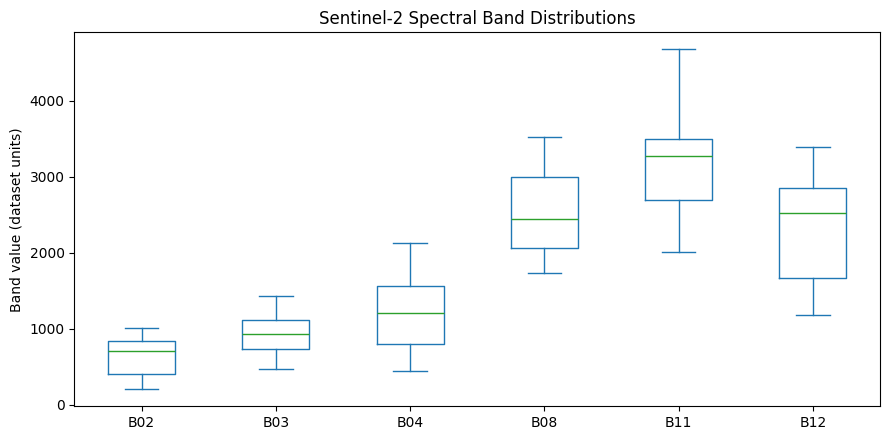

In [23]:
# Spectral band distributions
bands = [b for b in ["B02", "B03", "B04", "B08", "B11", "B12"] if b in optical.columns]
optical[bands].plot(kind="box", figsize=(9, 4.5), grid=False)
plt.title("Sentinel-2 Spectral Band Distributions")
plt.ylabel("Band value (dataset units)")
plt.tight_layout()
plt.show()

## 4. Sentinel-1 SAR test raster inspection

The TIFF is inspected as a test raster. Its VV/VH values must not be joined to optical records unless the raster's geographic footprint is confirmed to overlap the relevant YieldSAT sample locations.

In [24]:
tif_path = DATA_DIR / "SAR_VV_VH_Test.tif"
with rasterio.open(tif_path) as src:
    print("Raster dimensions (width, height):", src.width, src.height)
    print("Band count:", src.count)
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    print("NoData value:", src.nodata)
    print("Band descriptions:", src.descriptions)
    vv = src.read(1, masked=True)
    vh = src.read(2, masked=True) if src.count >= 2 else None

print("\\nVV summary:")
print(pd.Series(np.asarray(vv.compressed())).describe())
if vh is not None:
    print("\\nVH summary:")
    print(pd.Series(np.asarray(vh.compressed())).describe())

Raster dimensions (width, height): 11 11
Band count: 2
CRS: EPSG:32614
Transform: | 10.00, 0.00, 272470.10|
| 0.00,-10.00, 4049858.74|
| 0.00, 0.00, 1.00|
NoData value: None
Band descriptions: ('VV', 'VH')
\nVV summary:
count    121.000000
mean     -13.910384
std        2.166570
min      -20.682638
25%      -15.223745
50%      -13.759635
75%      -12.355667
max      -10.134101
dtype: float64
\nVH summary:
count    121.000000
mean     -20.081772
std        2.904315
min      -27.428113
25%      -22.277895
50%      -19.661013
75%      -17.633650
max      -15.482434
dtype: float64


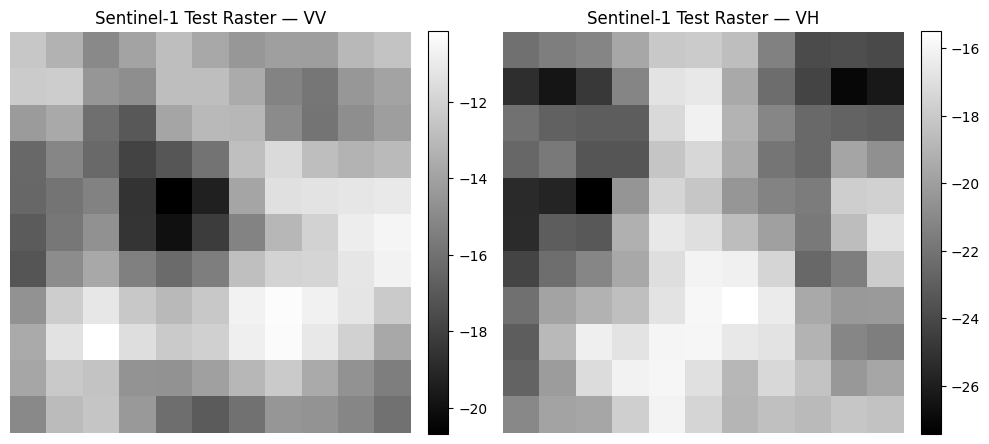

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
im1 = axes[0].imshow(vv, cmap="gray")
axes[0].set_title("Sentinel-1 Test Raster — VV")
axes[0].set_axis_off()
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

if vh is not None:
    im2 = axes[1].imshow(vh, cmap="gray")
    axes[1].set_title("Sentinel-1 Test Raster — VH")
    axes[1].set_axis_off()
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5. SAR extraction audit and integration decision

The supplied `SAR_Field_VV_VH_Samples.csv` is checked for valid VV/VH values and non-empty geometries. Empty geometry or missing values indicate that these rows cannot currently provide field-level SAR features.

In [26]:
for band in ["VV", "VH"]:
    if band in sar_samples.columns:
        valid = pd.to_numeric(sar_samples[band], errors="coerce").notna()
        print(f"{band}: {int(valid.sum())} valid values out of {len(sar_samples)}")

if ".geo" in sar_samples.columns:
    geo_text = sar_samples[".geo"].fillna("").astype(str)
    empty_geo = geo_text.str.contains(r'"coordinates"\s*:\s*\[\s*\]', regex=True)
    print("Empty-geometry records:", int(empty_geo.sum()), "out of", len(sar_samples))

print("Conclusion: do not merge the SAR test raster or unverified SAR samples with the optical records.")

VV: 0 valid values out of 100
VH: 0 valid values out of 100
Empty-geometry records: 100 out of 100
Conclusion: do not merge the SAR test raster or unverified SAR samples with the optical records.


## 6. Preliminary results and observations

- The available optical feature table contains 100 records from Argentina and Brazil.
- The supplied exploratory analysis reports 34 corn, 34 soybean, and 32 wheat records.
- The supplied NDVI analysis reports values approximately from 0.188 to 0.676, with a mean near 0.357. Re-check the exact values using the summary output above.
- The crop-wise plots show variation, but clear crop separation has not been established.
- The SAR TIFF provides a VV/VH visualization for a test raster only. Report its statistics only as test-raster statistics.
- The SAR field-sample table has empty VV/VH values and empty geometries; valid field-level extraction and optical–SAR matching are therefore not established.
- No classifier is trained in Week 3. ML experiments are planned for later weeks.

## 7. Outputs

This notebook saves:
- `Week3_optical_features_verified.csv` — optical records with recalculated NDVI.
- `Week3_data_quality_summary.csv` — basic data-quality checks.
- `Week3_crop_counts.csv` — sample counts by crop.

In [27]:
output_dir = DATA_DIR
optical.to_csv(output_dir / "Week3_optical_features_verified.csv", index=False)

quality_rows = []
for name, frame in [
    ("Argentina", argentina),
    ("Brazil", brazil),
    ("Optical features", optical),
    ("SAR field samples", sar_samples),
]:
    quality_rows.append({
        "dataset": name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "duplicate_rows": int(frame.duplicated().sum()),
        "missing_cells": int(frame.isna().sum().sum())
    })
pd.DataFrame(quality_rows).to_csv(output_dir / "Week3_data_quality_summary.csv", index=False)

optical["crop"].value_counts(dropna=False).rename_axis("crop").reset_index(name="records").to_csv(
    output_dir / "Week3_crop_counts.csv", index=False
)

print("Saved Week-3 outputs to:", output_dir)

Saved Week-3 outputs to: /content
